# Tests to compare everything with each other

## Verglecih der biophysikalischen Merkmale von CDR-H3, H2 und H3 zwischen den einzlennen Spezien 

- ANOVO:
    - Prüft, ob es einen signifikanten Unterschied im Mittelwert der Eigenschaft zwischen den drei Gruppen gibt

!! ANOVA sagt nicht, wo genau der Unterschied liegt – nur, ob überhaupt einer da ist

     => Gibt den p-Wert aus dem ANOVA-Test aus
     
→ Ein Wert kleiner als 0.05 gilt oft als signifikant


### CDR H3

In [475]:
import pandas as pd
from scipy.stats import f_oneway

# Load the dataset
df = pd.read_csv("all_data.tsv", sep="\t")

# Properties to be analyzed
properties = ['mean_hydrophobicity', 'mean_charge', 'mean_polarity', 'mean_mass'] 

# Perform ANOVA test for each property
for prop in properties:
    column = f'CDR_H3_{prop}'
    
    # Extract groups
    group_human = df[df["source"] == "human"][column].dropna()
    group_sars = df[df["source"] == "sars_cov2"][column].dropna()
    group_influenza = df[df["source"] == "influenza"][column].dropna()
    
    # ANOVA test
    f_stat, p_val = f_oneway(group_human, group_sars, group_influenza)
    
    # Print result
    print(f"{column} – ANOVA p-value: {p_val:.4f}")


CDR_H3_mean_hydrophobicity – ANOVA p-value: 0.2851
CDR_H3_mean_charge – ANOVA p-value: 0.0000
CDR_H3_mean_polarity – ANOVA p-value: 0.0022
CDR_H3_mean_mass – ANOVA p-value: 0.0000


### to be investigated further : 

#### - CDR_H3_mean_charge, 
#### - CDR_H3_mean_polarity, 
#### - CDR_H3_mean_mass

### CDR_H3_mean_polarity

In [476]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")

# Spalte für Analyse
column = 'CDR_H3_mean_polarity'

# Nur gültige Werte
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test
tukey_result = pairwise_tukeyhsd(
    endog=df_clean[column],      # abhängige Variable (Werte)
    groups=df_clean["source"],   # Gruppierung (z. B. human/sars/influenza)
    alpha=0.05                   # Signifikanzniveau
)

# Ergebnis anzeigen
print(tukey_result)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1    group2  meandiff p-adj   lower  upper  reject
---------------------------------------------------------
    human influenza   0.0765 0.4264 -0.0676 0.2206  False
    human sars_cov2   0.1392 0.0014  0.0461 0.2324   True
influenza sars_cov2   0.0628 0.5631 -0.0814 0.2069  False
---------------------------------------------------------


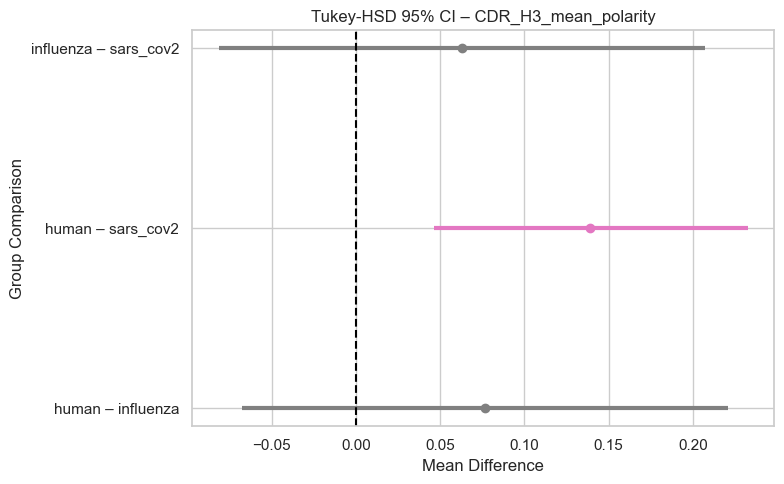

In [477]:
import matplotlib.pyplot as plt

# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
column = 'CDR_H3_mean_polarity'  

# Nur gültige Werte auswählen
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test durchführen
tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# Datentypen korrekt setzen
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)

# Farbzuweisung NUR nach Signifikanz
def get_color(row):
    return "tab:pink" if row["reject"] else "gray"

summary_df["color"] = summary_df.apply(get_color, axis=1)

# Plot erstellen
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [
    f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()
])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


### Interpretation:
#### CDR-H3 von humanen-Antikörper haben höhere Polarität im Schnitt

### CDR_H3_mean_charge

In [478]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")

# Spalte für Analyse
column = 'CDR_H3_mean_charge'

# Nur gültige Werte
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test
tukey_result = pairwise_tukeyhsd(
    endog=df_clean[column],      # abhängige Variable (Werte)
    groups=df_clean["source"],   # Gruppierung (z. B. human/sars/influenza)
    alpha=0.05                   # Signifikanzniveau
)

# Ergebnis anzeigen
print(tukey_result)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
    human influenza   0.0235 0.1578 -0.0065  0.0535  False
    human sars_cov2  -0.0303 0.0008 -0.0497 -0.0109   True
influenza sars_cov2  -0.0538 0.0001 -0.0837 -0.0238   True
----------------------------------------------------------


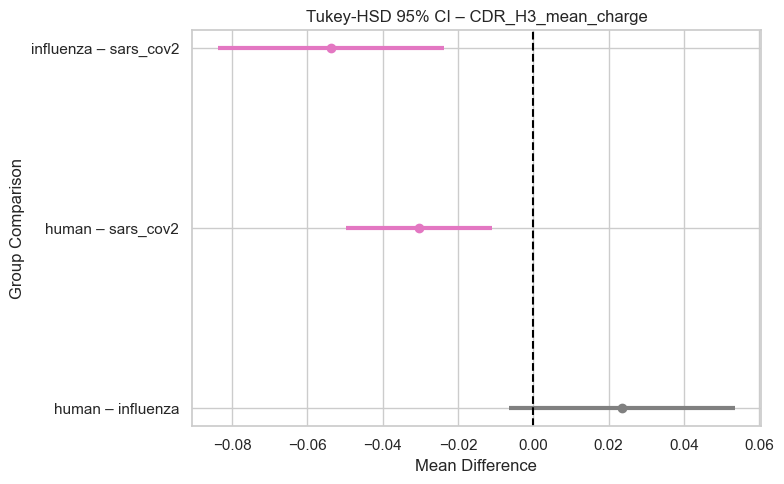

In [479]:
import matplotlib.pyplot as plt

# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
column = 'CDR_H3_mean_charge'  

# Nur gültige Werte auswählen
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test durchführen
tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# Datentypen korrekt setzen
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)

# Farbzuweisung NUR nach Signifikanz
def get_color(row):
    return "tab:pink" if row["reject"] else "gray"

summary_df["color"] = summary_df.apply(get_color, axis=1)

# Plot erstellen
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [
    f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()
])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


### Interpretation:
#### - mittlere Ladung in der CDR-H3-Region ist bei SARS-CoV-2-Antikörpern höher als bei humanen Antikörpern
#### - mittlere Ladung in CDR-H3-Region ist bei SARS-CoV-2-Antikörper höher als bei Influenza
#### => Antikörper gegen SARS-CoV-2 zeigen eine signifikant höhere mittlere Ladung in der CDR-H3-Region als Antikörper gegen Influenza oder aus der humanen Kontrollgruppe

In [480]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")

# Spalte für Analyse
column = 'CDR_H3_mean_mass'

# Nur gültige Werte
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test
tukey_result = pairwise_tukeyhsd(
    endog=df_clean[column],      # abhängige Variable (Werte)
    groups=df_clean["source"],   # Gruppierung (z. B. human/sars/influenza)
    alpha=0.05                   # Signifikanzniveau
)

# Ergebnis anzeigen
print(tukey_result)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
    human influenza  -2.3716 0.0719 -4.9038  0.1605  False
    human sars_cov2  -3.4288    0.0 -5.0661 -1.7915   True
influenza sars_cov2  -1.0572 0.5897 -3.5901  1.4757  False
----------------------------------------------------------


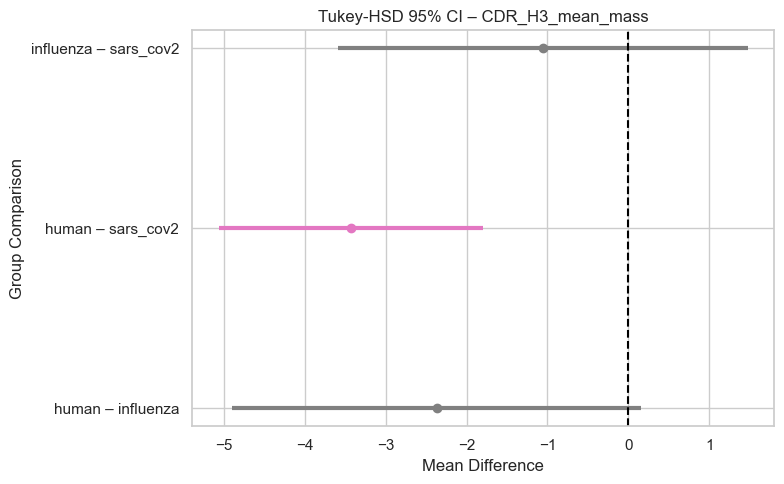

In [481]:
import matplotlib.pyplot as plt

# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
column = 'CDR_H3_mean_mass'  

# Nur gültige Werte auswählen
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test durchführen
tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# Datentypen korrekt setzen
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)

# Farbzuweisung NUR nach Signifikanz
def get_color(row):
    return "tab:pink" if row["reject"] else "gray"

summary_df["color"] = summary_df.apply(get_color, axis=1)

# Plot erstellen
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [
    f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()
])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


#### Erklärurng Plot

= Visualisierung **Tukey-HSD-Analyse** 

= **graphische Darstellung der Ergebnisse des Tukey-HSD-Tests** für die Variable `CDR_H3_mean_polarity`.

### Achsen & Bedeutung:

* **Y-Achse:** Paarweise Gruppenvergleiche 
* **X-Achse:** Mittelwertsdifferenz zwischen diesen Gruppen
* **Horizontale Linien:** 95 %-Konfidenzintervalle der Differenz
* **Punkte:** Der geschätzte Mittelwertsunterschied
* **Vertikale gestrichelte Linie:** Null-Linie (kein Unterschied)

### Farben:

* ** Rot:** Statistisch **signifikanter Unterschied** (p-Wert < 0.05)
* ** Grau:** Kein signifikanter Unterschied (p-Wert ≥ 0.05)

# ! Tukey-HSD-Test = Tukey’s Honest Significant Difference (HSD)

### = Post-hoc-Test
    = welche Gruppenpaare unterscheiden sich signifikant voneinander – welche Mittelwerte sind tatsächlich verschieden 

#### Verwendung

- bei signifikanten Unterschied: bei ANOVA p-Wert < 0,05

- bei mehrere Gruppen

- Um genau zu sehen, zwischen welchen Gruppen der Unterschied liegt

#### Wie funktioniert der Test:

- Differenz der Mittelwerte 

- Standardfehler der Differenz (berücksichtigt die Streuung innerhalb der Gruppen und die Anzahl der Stichproben (je größer n, desto genauer))

- Vergleich mit kritischem Wert
= Der kritische Wert stammt aus der studentisierten Range-Verteilung („q-Verteilung“) und hängt ab von:

- Anzahl der Gruppen k
- Anzahl aller Stichproben
- Signifikanzniveau α (meist 0.05)

#### Bedeutung

- meandiff: Mittelwertsunterschied

- p-adj: Adjustierter p-Wert

- lower / upper: Konfidenzintervall

- reject: True = signifikanter Unterschied









### CDR H2

In [482]:
# Load the dataset
df = pd.read_csv("all_data.tsv", sep="\t")

# Properties to be analyzed
properties = ['mean_hydrophobicity', 'mean_charge', 'mean_polarity', 'mean_mass'] 

# Perform ANOVA test for each property (CDR_H2)
for prop in properties:
    column = f'CDR_H2_{prop}'
    
    # Extract groups
    group_human = df[df["source"] == "human"][column].dropna()
    group_sars = df[df["source"] == "sars_cov2"][column].dropna()
    group_influenza = df[df["source"] == "influenza"][column].dropna()
    
    # ANOVA test
    f_stat, p_val = f_oneway(group_human, group_sars, group_influenza)
    
    # Print result
    print(f"{column} – ANOVA p-value: {p_val:.4f}")


CDR_H2_mean_hydrophobicity – ANOVA p-value: 0.0013
CDR_H2_mean_charge – ANOVA p-value: 0.0599
CDR_H2_mean_polarity – ANOVA p-value: 0.0647
CDR_H2_mean_mass – ANOVA p-value: 0.0981


In [483]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")

# Spalte für Analyse
column = 'CDR_H2_mean_hydrophobicity'

# Nur gültige Werte
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test
tukey_result = pairwise_tukeyhsd(
    endog=df_clean[column],      # abhängige Variable (Werte)
    groups=df_clean["source"],   # Gruppierung (z. B. human/sars/influenza)
    alpha=0.05                   # Signifikanzniveau
)

# Ergebnis anzeigen
print(tukey_result)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1    group2  meandiff p-adj   lower  upper  reject
---------------------------------------------------------
    human influenza    0.405 0.0021  0.1247 0.6853   True
    human sars_cov2   0.1861 0.0426  0.0048 0.3673   True
influenza sars_cov2  -0.2189 0.1594 -0.4993 0.0615  False
---------------------------------------------------------


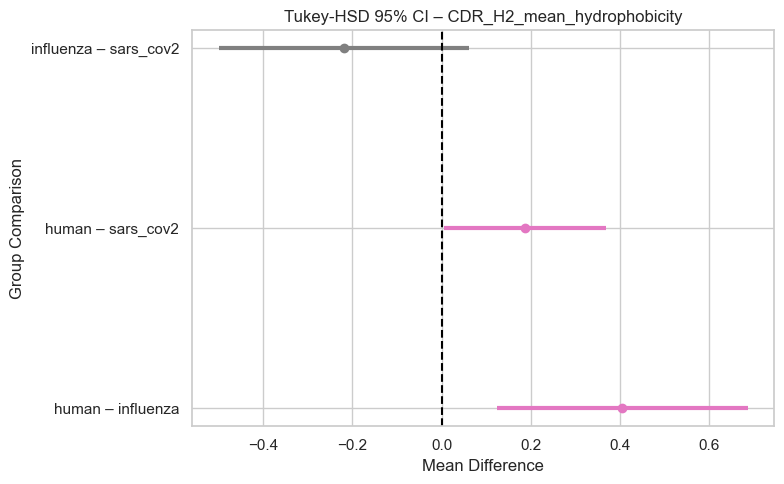

In [484]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
column = 'CDR_H2_mean_hydrophobicity'  

# Nur gültige Werte auswählen
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test durchführen
tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# Datentypen korrekt setzen
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)

# Farbzuweisung NUR nach Signifikanz
def get_color(row):
    return "tab:pink" if row["reject"] else "gray"

summary_df["color"] = summary_df.apply(get_color, axis=1)

# Plot erstellen
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [
    f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()
])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


### CDR H1

In [485]:
# Load the combined dataset
df = pd.read_csv("all_data.tsv", sep="\t")

# Properties to be analyzed
properties = ['mean_hydrophobicity', 'mean_charge', 'mean_polarity', 'mean_mass'] 

# Loop through each property (CDR_H1)
for prop in properties:
    column = f'CDR_H1_{prop}'
    
    # Extract groups
    group_human = df[df["source"] == "human"][column].dropna()
    group_sars = df[df["source"] == "sars_cov2"][column].dropna()
    group_influenza = df[df["source"] == "influenza"][column].dropna()
    
    # Perform ANOVA test
    f_stat, p_val = f_oneway(group_human, group_sars, group_influenza)
    
    # Print result
    print(f"{column} – ANOVA p-value: {p_val:.4f}")


CDR_H1_mean_hydrophobicity – ANOVA p-value: 0.0000
CDR_H1_mean_charge – ANOVA p-value: 0.6840
CDR_H1_mean_polarity – ANOVA p-value: 0.0000
CDR_H1_mean_mass – ANOVA p-value: 0.0000


In [489]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")

# Spalte für Analyse
column = 'CDR_H1_mean_hydrophobicity'

# Nur gültige Werte
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test
tukey_result = pairwise_tukeyhsd(
    endog=df_clean[column],      # abhängige Variable (Werte)
    groups=df_clean["source"],   # Gruppierung (z. B. human/sars/influenza)
    alpha=0.05                   # Signifikanzniveau
)

# Ergebnis anzeigen
print(tukey_result)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
    human influenza  -0.2332 0.0001 -0.3636 -0.1027   True
    human sars_cov2   0.1486 0.0001  0.0642   0.233   True
influenza sars_cov2   0.3818    0.0  0.2513  0.5123   True
----------------------------------------------------------


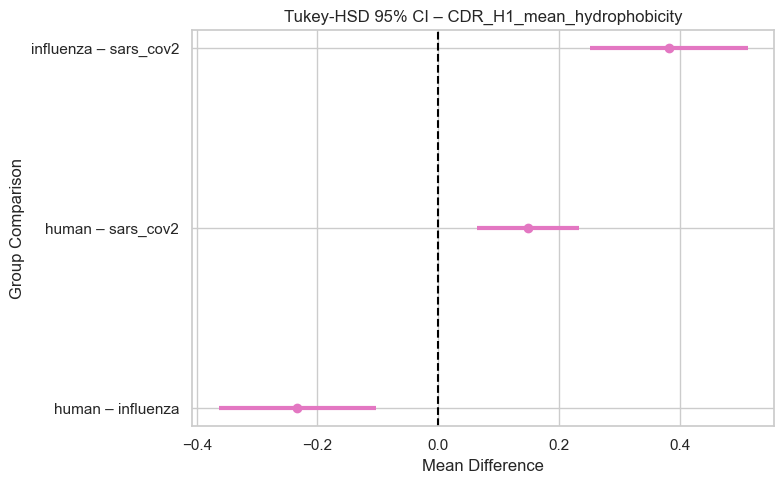

In [490]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
column = 'CDR_H1_mean_hydrophobicity'  

# Nur gültige Werte auswählen
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test durchführen
tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# Datentypen korrekt setzen
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)

# Farbzuweisung NUR nach Signifikanz
def get_color(row):
    return "tab:pink" if row["reject"] else "gray"

summary_df["color"] = summary_df.apply(get_color, axis=1)

# Plot erstellen
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [
    f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()
])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


In [491]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")

# Spalte für Analyse
column = 'CDR_H1_mean_polarity'

# Nur gültige Werte
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test
tukey_result = pairwise_tukeyhsd(
    endog=df_clean[column],      # abhängige Variable (Werte)
    groups=df_clean["source"],   # Gruppierung (z. B. human/sars/influenza)
    alpha=0.05                   # Signifikanzniveau
)

# Ergebnis anzeigen
print(tukey_result)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
    human influenza   0.3252    0.0  0.1823   0.468   True
    human sars_cov2   0.0419 0.5355 -0.0504  0.1343  False
influenza sars_cov2  -0.2832    0.0 -0.4261 -0.1403   True
----------------------------------------------------------


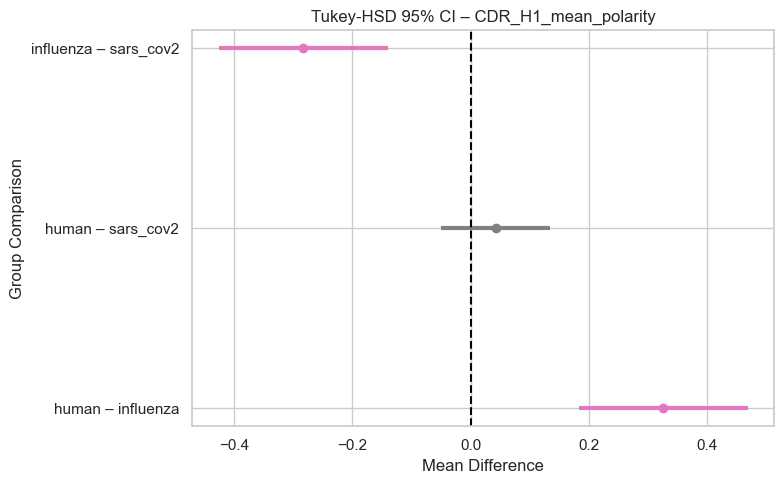

In [492]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
column = 'CDR_H1_mean_polarity'  

# Nur gültige Werte auswählen
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test durchführen
tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# Datentypen korrekt setzen
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)

# Farbzuweisung NUR nach Signifikanz
def get_color(row):
    return "tab:pink" if row["reject"] else "gray"

summary_df["color"] = summary_df.apply(get_color, axis=1)

# Plot erstellen
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [
    f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()
])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


In [493]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")

# Spalte für Analyse
column = 'CDR_H1_mean_mass'

# Nur gültige Werte
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test
tukey_result = pairwise_tukeyhsd(
    endog=df_clean[column],      # abhängige Variable (Werte)
    groups=df_clean["source"],   # Gruppierung (z. B. human/sars/influenza)
    alpha=0.05                   # Signifikanzniveau
)

# Ergebnis anzeigen
print(tukey_result)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
    human influenza  -4.9553    0.0 -7.5208 -2.3899   True
    human sars_cov2   -3.742    0.0 -5.4008 -2.0832   True
influenza sars_cov2   1.2133 0.5081 -1.3528  3.7795  False
----------------------------------------------------------


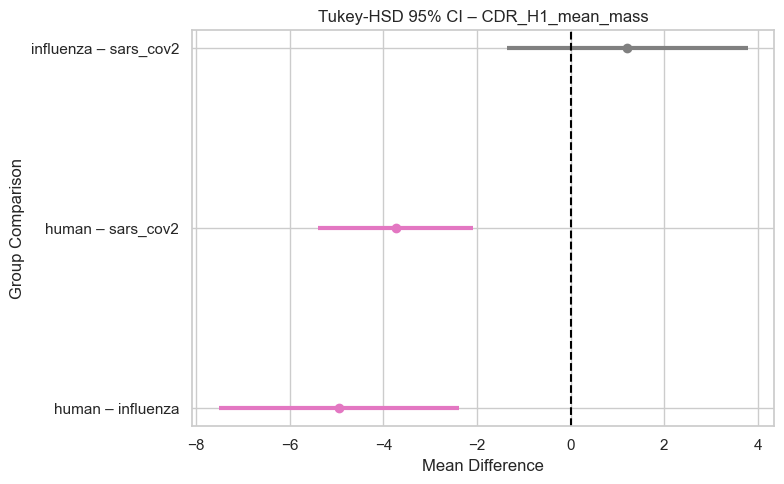

In [494]:
# Daten laden
df = pd.read_csv("all_data.tsv", sep="\t")
column = 'CDR_H1_mean_mass'  

# Nur gültige Werte auswählen
df_clean = df[[column, "source"]].dropna()

# Tukey-HSD-Test durchführen
tukey = pairwise_tukeyhsd(endog=df_clean[column], groups=df_clean["source"], alpha=0.05)
summary_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# Datentypen korrekt setzen
summary_df["meandiff"] = summary_df["meandiff"].astype(float)
summary_df["lower"] = summary_df["lower"].astype(float)
summary_df["upper"] = summary_df["upper"].astype(float)
summary_df["reject"] = summary_df["reject"].astype(bool)

# Farbzuweisung NUR nach Signifikanz
def get_color(row):
    return "tab:pink" if row["reject"] else "gray"

summary_df["color"] = summary_df.apply(get_color, axis=1)

# Plot erstellen
plt.figure(figsize=(8, 5))
for i, row in summary_df.iterrows():
    plt.hlines(y=i, xmin=row["lower"], xmax=row["upper"], color=row["color"], lw=3)
    plt.plot(row["meandiff"], i, 'o', color=row["color"])

plt.axvline(x=0, color="black", linestyle="--")
plt.yticks(range(len(summary_df)), [
    f"{row['group1']} – {row['group2']}" for _, row in summary_df.iterrows()
])
plt.title(f"Tukey-HSD 95% CI – {column}")
plt.xlabel("Mean Difference")
plt.ylabel("Group Comparison")
plt.tight_layout()
plt.show()


## Compare lengths

/var/folders/s2/qtqytml16zj3cmryjfpnnl7r0000gn/T/ipykernel_12385/2603186215.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="source", y=region, estimator="mean", errorbar="sd", palette="pastel")


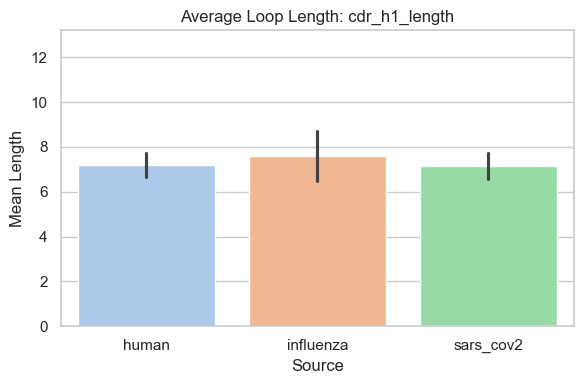

 cdr_h1_length – ANOVA p-value: 0.0000


/var/folders/s2/qtqytml16zj3cmryjfpnnl7r0000gn/T/ipykernel_12385/2603186215.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="source", y=region, estimator="mean", errorbar="sd", palette="pastel")


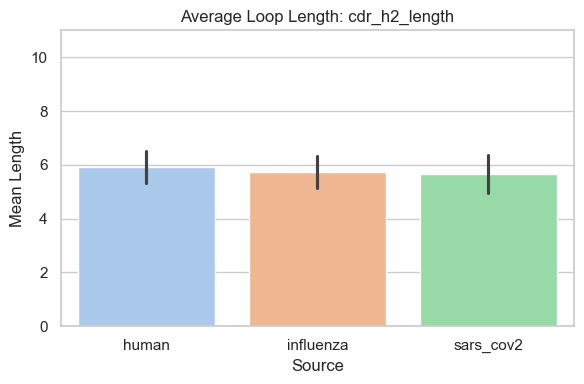

/var/folders/s2/qtqytml16zj3cmryjfpnnl7r0000gn/T/ipykernel_12385/2603186215.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="source", y=region, estimator="mean", errorbar="sd", palette="pastel")


 cdr_h2_length – ANOVA p-value: 0.0000


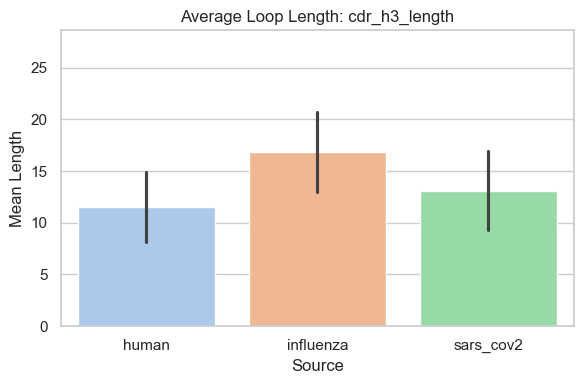

 cdr_h3_length – ANOVA p-value: 0.0000


In [486]:


# Load merged dataset
df = pd.read_csv("all_data_normalized.tsv", sep="\t")

# Regions to analyze
regions = ["cdr_h1_length", "cdr_h2_length", "cdr_h3_length"]

# Loop through each region
for region in regions:
    plt.figure(figsize=(6, 4))

    # Barplot with error bars (standard deviation)
    sns.barplot(data=df, x="source", y=region, estimator="mean", errorbar="sd", palette="pastel")

    plt.title(f"Average Loop Length: {region}")
    plt.xlabel("Source")
    plt.ylabel("Mean Length")
    plt.ylim(0, df[region].max() * 1.1)  # Avoid negative axis
    plt.tight_layout()
    plt.show()

    # ANOVA test
    group_human = df[df["source"] == "human"][region].dropna()
    group_sars = df[df["source"] == "sars_cov2"][region].dropna()
    group_influenza = df[df["source"] == "influenza"][region].dropna()

    f_stat, p_val = f_oneway(group_human, group_sars, group_influenza)
    print(f" {region} – ANOVA p-value: {p_val:.4f}")


## AS Zusammensetzung


 Generating heatmap for CDR_H1...


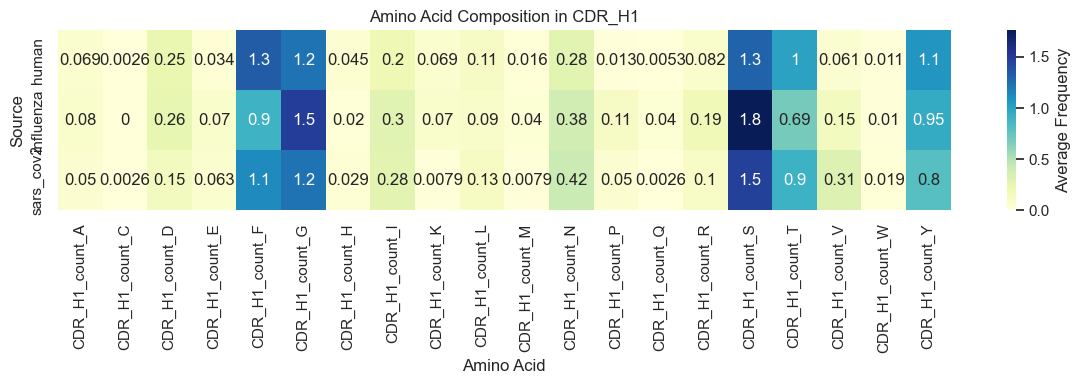


 Generating heatmap for CDR_H2...


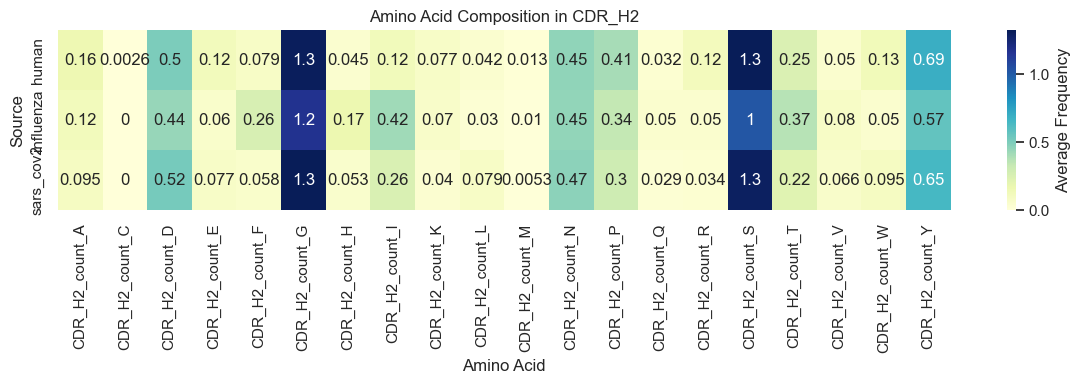


 Generating heatmap for CDR_H3...


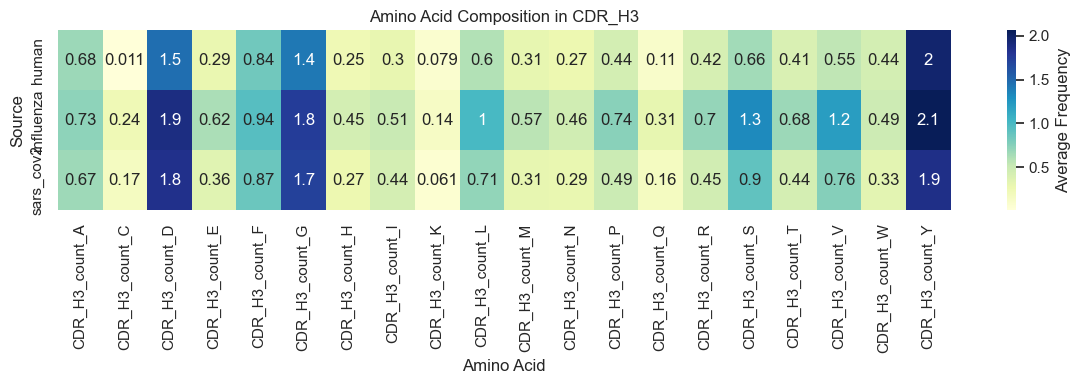

In [487]:
# Load the combined dataset
df = pd.read_csv("all_data_normalized.tsv", sep="\t")

# Loop over all CDR regions
for cdr in ["CDR_H1", "CDR_H2", "CDR_H3"]:
    print(f"\n Generating heatmap for {cdr}...")
    
    # Find columns that count amino acids for this CDR
    aa_columns = [col for col in df.columns if col.startswith(f"{cdr}_count_")]
    
    if not aa_columns:
        print(f" No count columns found for {cdr}")
        continue

    # Group by source and calculate the mean
    heatmap_data = df.groupby("source")[aa_columns].mean()

    # Sort columns alphabetically
    heatmap_data = heatmap_data[sorted(heatmap_data.columns)]

    # Plot the heatmap
    plt.figure(figsize=(12, 4))
    sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", cbar_kws={"label": "Average Frequency"})
    plt.title(f"Amino Acid Composition in {cdr}")
    plt.xlabel("Amino Acid")
    plt.ylabel("Source")
    plt.tight_layout()
    plt.show()


## Relative AS Verteilung


Generating barplot for CDR_H1 (relative frequencies)...


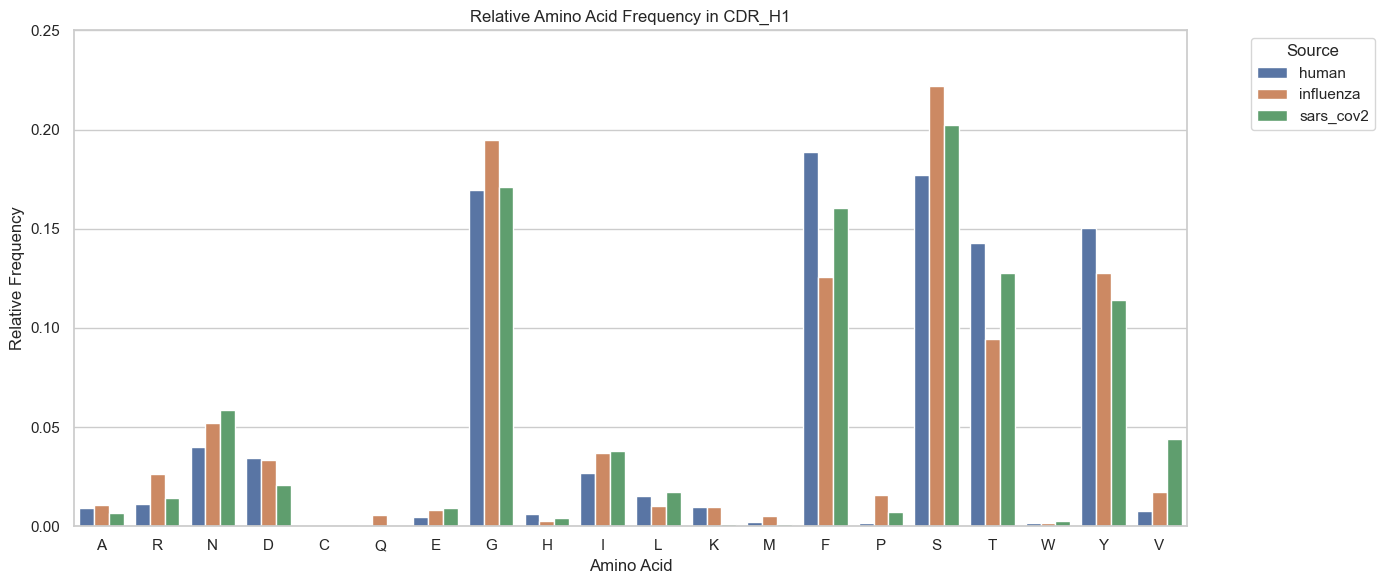


Generating barplot for CDR_H2 (relative frequencies)...


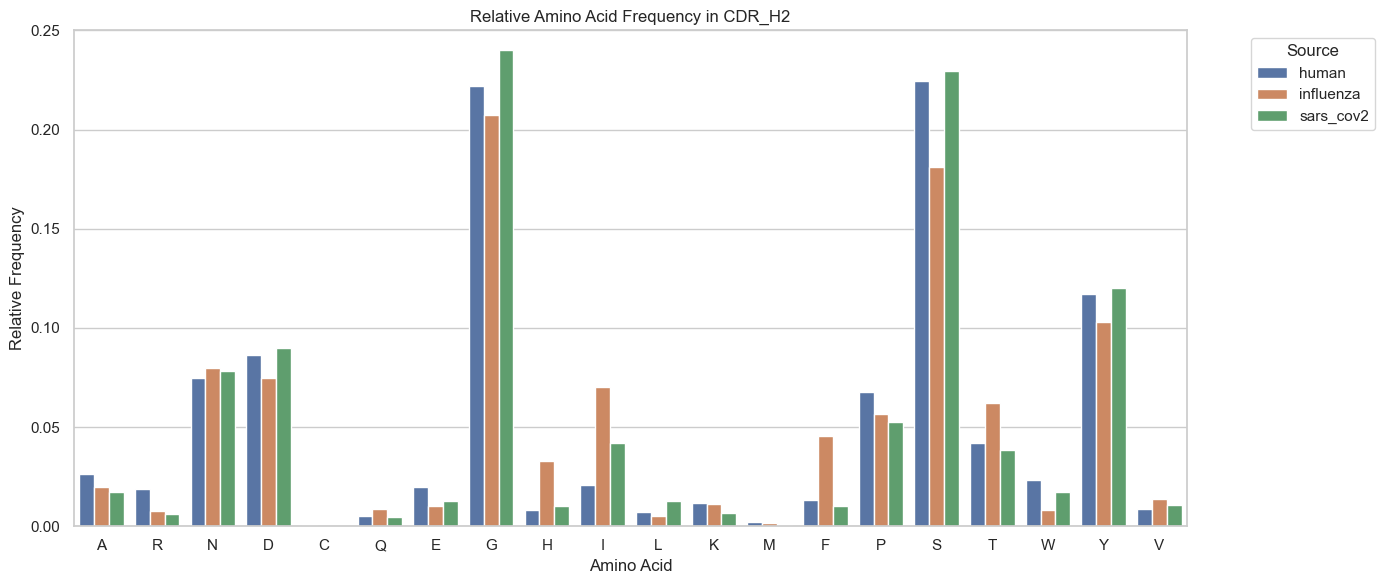


Generating barplot for CDR_H3 (relative frequencies)...


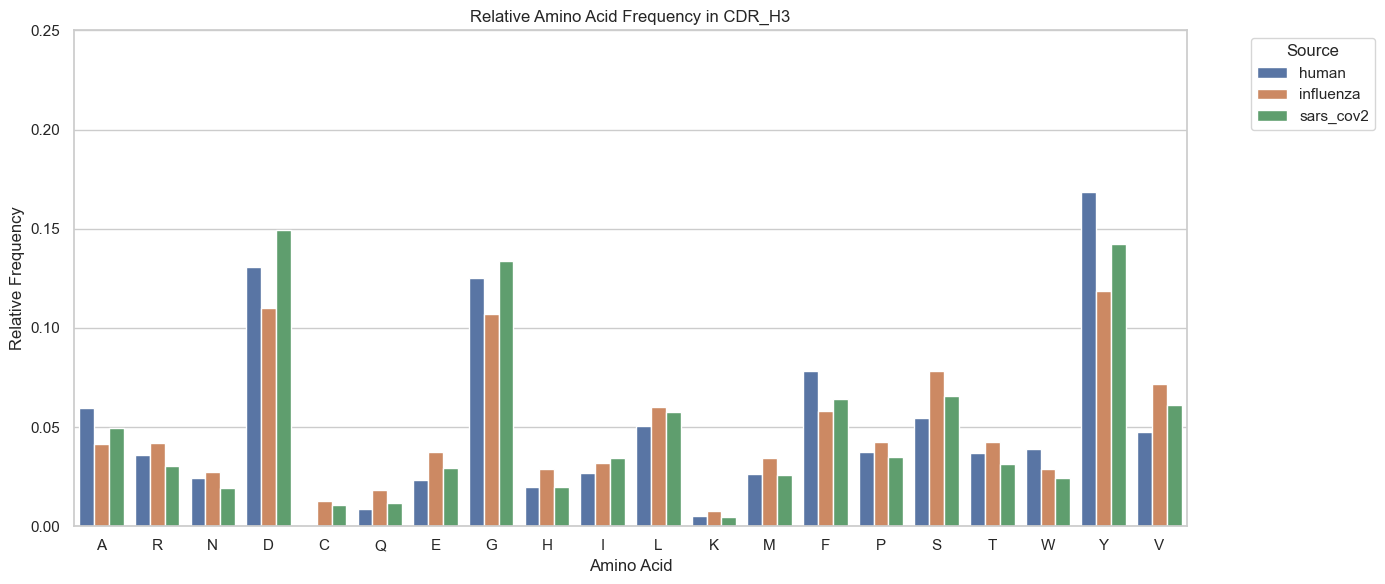

In [488]:
# Load the normalized dataset
df = pd.read_csv("all_data_normalized.tsv", sep="\t")

# Loop over all CDR regions
for cdr in ["CDR_H1", "CDR_H2", "CDR_H3"]:
    print(f"\nGenerating barplot for {cdr} (relative frequencies)...")

    # Finde alle relfreq-Spalten für diese CDR
    relfreq_cols = [col for col in df.columns if col.startswith(f"{cdr}_relfreq_")]

    if not relfreq_cols:
        print(f"No relative frequency columns found for {cdr}")
        continue

    # Gruppiere nach Quelle und berechne Mittelwerte
    grouped = df.groupby("source")[relfreq_cols].mean().reset_index()

    # In langes Format umwandeln
    long_df = grouped.melt(
        id_vars="source",
        value_vars=relfreq_cols,
        var_name="aa_column",
        value_name="relfreq"
    )

    # Aminosäure extrahieren (z. B. CDR_H1_relfreq_A → A)
    long_df["Amino Acid"] = long_df["aa_column"].str.replace(f"{cdr}_relfreq_", "", regex=False)

    # Plot
    plt.figure(figsize=(14, 6))
    sns.barplot(data=long_df, x="Amino Acid", y="relfreq", hue="source")
    plt.title(f"Relative Amino Acid Frequency in {cdr}")
    plt.ylim(0, 0.25)  # Skala von 0 bis 1 (entspricht 0 % bis 100 %)
    plt.xlabel("Amino Acid")
    plt.ylabel("Relative Frequency")
    plt.legend(title="Source", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
